# GT+ML+NLP ideas

**Багатовимірний аналіз векторних представлень тексту із застосуванням машинного навчання та змагальних моделей**

1. Unrolled GAN
2. Prediction methods (зокрема Optimistic Mirror Descent)
3. Wasserstein GAN (WGAN-GP)
4. Prediction methods, Lookahead-minmax


# "Мінмаксні принципи та сідлові точки у просторах семантичних представлень тексту"


## 1. Adversarial Word Embeddings як гра двох гравців

Класичний Word2Vec шукає

$$
\max_{\theta} L(\theta)
$$

де $\theta$ — embedding-и слів.

Але можна побудувати гру: генератор створює embedding-и; дискримінатор намагається визначити, чи вони "природні"

Тоді отримуємо

$$
\min_D \max_G V(G,D)
$$

як у GAN.

Класичний Word2Vec навчається так:

Для центрального слова (w) потрібно зробити embedding

$$
e_w\in\mathbb R^d
$$

таким, щоб він добре передбачав контекст.

Наприклад, Skip-Gram максимізує

$$
L(E)=
\sum_{(w,c)}
\log P(c|w).
$$

Тобто ми просто шукаємо

$$
\max_E L(E).
$$

Нехай тепер існує

* **Generator** (G)
* **Adversary** (A)

Generator будує embedding

$$ e=G(w). $$

Після цього adversary намагається його "зіпсувати".

Наприклад

$$ \tilde e=e+\delta. $$

де $\delta$ — спеціально знайдене збурення.

Generator хоче, щоб навіть після такого збурення embedding залишався семантично правильним.

Adversary хоче, максимально його зруйнувати.

Отримуємо гру

$$
\min_A
\max_G
V(G,A).
$$

**Що означає "зіпсувати embedding"?**

Наприклад,

Generator видає

```
cat
```

↓

```
[0.42
-0.11
...
]
```

Adversary додає

```
+0.03
-0.07
...
```

Після цього найближчим словом стає

```
dog
```

або навіть

```
car
```

Generator програв.


**Цикл навчання**

```
Generator

↓

Embedding

↓

Adversary

↓

Perturbed embedding

↓

Context prediction

↓

Generator update

↓

Adversary update
```

**Варіанти**: семантична відстань (множина найближчих сусідів embedding, штрафуємо за зміну сусідів), Cosine Similarity (мінімізуємо $\cos(e,\tilde e)$), Класифікація (Embedding подаємо у класифікатор, generator хлче залишити positive, adv. - negative).

**Як реалізувати Generator**: 
- Generator звичайний Word2Vec, Він виробляє embedding.
- Generator — невеликий MLP

**Adversary**: не генерує слова, генерує $\delta$, Embedding -> NN -> $\delta$ -> embedding + $\delta$.




## 2. Embedding Space як многовид

Сучасні embedding-и (BERT, SBERT, E5, GTE) живуть у просторах

$$
\mathbb R^{384},
\mathbb R^{768},
\mathbb R^{1024}
$$

Але реально вони лежать на деякому многовиді меншої розмірності.

Можна розглядати задачу:

$$ \min_x \max_y f(x,y) $$

де (x) — напрямок семантичної зміни, (y) — напрямок шуму, та досліджувати сідлові точки.

## 3. Теорія ігор для семантичної стабільності



## 4. Аналог теореми фон Неймана для embedding-просторів



## 5. GAN для побудови кращих embedding-ів

Замість використання готового BERT. Generator $G(w)$ створює embedding. Discriminator $D(v)$ намагається визначити реальний embedding чи згенерований.

Можна досліджувати:

* збіжність;
* структуру сідлових точок;
* локальні мінімуми.

## 6. Adversarial Attacks на Embeddings


## 7. Wasserstein GAN + текстові представлення



## 8. Fuzzy-GAN для текстових представлень



In [1]:
# Adversarial Word Embeddings as the game of two players

import numpy as np
from scipy.optimize import differential_evolution
from sentence_transformers import SentenceTransformer
from numpy.linalg import norm

model = SentenceTransformer("all-MiniLM-L6-v2")

sentence = "The patient suffers from fever and cough."

embedding = model.encode(sentence)
embedding = embedding.astype(np.float64)

def cosine(a,b):
    return np.dot(a,b)/(norm(a)*norm(b))

EPS = 0.5 # limitation

# loss
def objective(delta):
    delta=np.array(delta)
    if norm(delta)>EPS:
        return 1000
    perturbed=embedding+delta
    similarity=cosine(
        embedding,
        perturbed
    )

    return similarity

# optimization
bounds=[(-0.2,0.2)]*embedding.shape[0]

result=differential_evolution(
    objective,
    bounds,
    maxiter=40,
    popsize=10,
    seed=42
)

delta=result.x

perturbed=embedding+delta

print(cosine(embedding, perturbed))


# find closest sentences
corpus=[
"The patient has influenza.",
"The patient suffers from pneumonia.",
"The weather is sunny today.",
"Artificial intelligence is transforming medicine.",
"The patient reports cough and fever.",
"He likes football."
]

corpus_embeddings=model.encode(corpus)

# search function
def nearest(vector,k=3):
    similarities=[]
    for i,e in enumerate(corpus_embeddings):
        sim=cosine(vector,e)
        similarities.append((sim,corpus[i]))
    similarities.sort(reverse=True)

    return similarities[:k]

print("Original")

for sim,text in nearest(embedding):
    print(sim,text)

print()

print("Perturbed")

for sim,text in nearest(perturbed):
    print(sim,text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

0.42007926351365577
Original
0.9402774739355119 The patient reports cough and fever.
0.7212866195046193 The patient has influenza.
0.6998644295605936 The patient suffers from pneumonia.

Perturbed
0.38940227980578856 The patient reports cough and fever.
0.3115835266792639 The patient has influenza.
0.2217802748870587 The patient suffers from pneumonia.



Iteration 0
Attack cosine 0.4365157620166917
Recovered cosine 0.20625858403177136
Loss 0.9799438118934631

Iteration 1
Attack cosine 0.48511823637167084
Recovered cosine 0.3312781885811681
Loss 0.8358351588249207

Iteration 2
Attack cosine 0.43792922975390686
Recovered cosine 0.44079236883858663
Loss 0.7178685665130615

Iteration 3
Attack cosine 0.425434967306418
Recovered cosine 0.5042057969241355
Loss 0.649431049823761

Iteration 4
Attack cosine 0.4415959801668359
Recovered cosine 0.6438716037381778
Loss 0.4827318787574768

Iteration 5
Attack cosine 0.46561395075929685
Recovered cosine 0.7130499594050098
Loss 0.4026676416397095

Iteration 6
Attack cosine 0.3438328064690462
Recovered cosine 0.7460724024173205
Loss 0.3613172173500061

Iteration 7
Attack cosine 0.414061941405772
Recovered cosine 0.8235947141933843
Loss 0.24754518270492554

Iteration 8
Attack cosine 0.4031760028789048
Recovered cosine 0.8671392652885989
Loss 0.17665314674377441

Iteration 9
Attack cosine 0.4748464164811

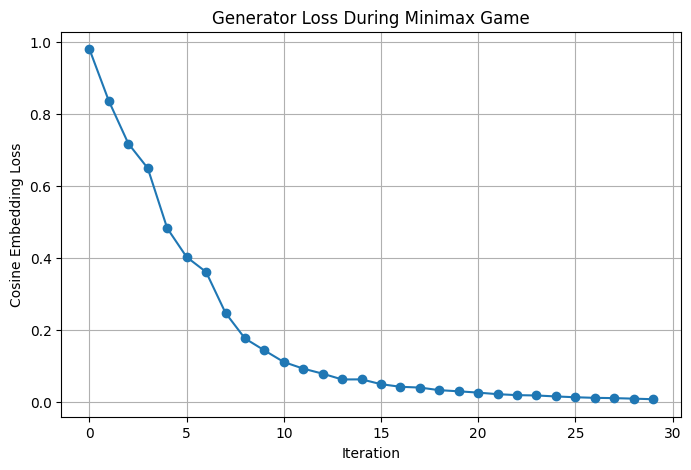

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),

            nn.Linear(256,256),
            nn.ReLU(),

            nn.Linear(256,dim)
        )

    def forward(self,x):
        return self.net(x)
    
generator = Generator(embedding.shape[0])

optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=1e-3
)

def attack(current_embedding):

    def objective(delta):
        delta=np.array(delta)
        if norm(delta)>EPS:
            return 1000

        perturbed=current_embedding+delta
        recovered=generator(
            torch.tensor(
                perturbed,
                dtype=torch.float32
            )
        ).detach().numpy()

        return cosine(
            embedding,
            recovered
        )

    bounds=[(-0.2,0.2)]*len(current_embedding)
    result=differential_evolution(
        objective,
        bounds,
        maxiter=20,
        popsize=10
    )

    return result.x

loss_fn = nn.CosineEmbeddingLoss()

def train_generator(perturbed):
    optimizer.zero_grad()

    x=torch.tensor(
        perturbed,
        dtype=torch.float32
    )

    target=torch.tensor(
        embedding,
        dtype=torch.float32
    )

    recovered=generator(x)
    label=torch.tensor([1.0])
    loss=loss_fn(
        recovered.unsqueeze(0),
        target.unsqueeze(0),
        label
    )

    loss.backward()
    optimizer.step()
    return loss.item()

# Store losses
loss_history = []

# THE GAME LOOP
for iteration in range(30):

    # Player 2 attacks
    delta=attack(embedding)
    perturbed=embedding+delta

    # Player 1 responds
    loss=train_generator(perturbed)
    loss_history.append(loss)

    recovered=generator(
        torch.tensor(
            perturbed,
            dtype=torch.float32
        )
    ).detach().numpy()

    print()

    print("Iteration",iteration)

    print("Attack cosine",
          cosine(embedding,perturbed))

    print("Recovered cosine",
          cosine(embedding,recovered))

    print("Loss",loss)

# Plot loss history
plt.figure(figsize=(8,5))
plt.plot(loss_history, marker='o')
plt.title("Generator Loss During Minimax Game")
plt.xlabel("Iteration")
plt.ylabel("Cosine Embedding Loss")
plt.grid(True)
plt.show()

# Embedding Space як многовид

## 1. Основна гіпотеза

Нехай $E:\mathcal T\rightarrow \mathbb R^d$ - embedding-модель (Sentence-BERT, E5, GTE тощо). Для тексту $t$ отримуємо $z=E(t)\in\mathbb R^d`$

Формально $d=384,768,1024,\ldots$, але емпірично всі embedding-и не заповнюють увесь простір. Вони лежать приблизно на деякому компактному многовиді $\mathcal M\subset\mathbb R^d$, де $\dim(\mathcal M)\ll d.$

Саме ця гіпотеза підтверджується багатьма роботами з manifold learning.


## 2. Локальна геометрія многовиду

Нехай $z\in\mathcal M.$ У точці існує дотичний простір $T_z\mathcal M.$ Його можна оцінити через PCA над найближчими сусідами embedding-а.

Наприклад, беремо $k=50$ найближчих текстів.

Будуємо матрицю

$$
X=
\begin{bmatrix}
z_1-z\\
z_2-z\\
\vdots\\
z_k-z
\end{bmatrix}.
$$

PCA дає $u_1,\ldots,u_r,$ які апроксимують $T_z\mathcal M.$


## 3. Декомпозиція напрямків

Тепер кожен вектор $\delta$ розкладається як $\delta=\delta_T+\delta_N,$ де $\delta_T\in T_z\mathcal M$ — семантичний напрямок, а $\delta_N\perp T_z\mathcal M$ — нормальний напрямок.

Інтуїтивно

* рух уздовж многовиду змінює зміст;
* рух перпендикулярно — породжує шум або "неприродні" embedding-и.

Саме тут з'являється геометрична інтерпретація шуму.


## 4. Семантичний функціонал

Нехай $q$— початковий текст, а $d(q)$ — еталонний документ. Розглянемо $S(z)=\cos(E(q),z).$ Або $S(z)=-|E(d)-z|^2.$ Це функція "семантичної якості".

## 5. Мінмаксна задача

Тепер вводимо двох "гравців". Перший рухає embedding уздовж многовиду $u\in T_z\mathcal M.$ Другий — додає шум $v\in N_z\mathcal M.$ 

Отримуємо $z'=z+u+v.$ Функціонал $F(u,v)=S(z+u+v).$ Перший хоче $\max_uF(u,v),$ другий $\min_vF(u,v).$

Разом

$$
\boxed{
\max_{u\in T_z\mathcal M}
\min_{v\in N_z\mathcal M}
F(u,v)
}
$$

або

$$
\boxed{
\min_v
\max_u
F(u,v).
}
$$

## 6. Сідлова точка

Сідлова точка $(u^*,v^*)$ визначається умовою 

$F(u,v^*)
\le
F(u^*,v^*)
\le
F(u^*,v).$

Тобто

* жоден семантичний рух не покращує якість;
* жоден шум не може зробити її гіршою.

Саме така точка відповідає "стабільному" embedding.


## 7. Через градієнти

Припустимо $F$ диференційована. Тоді $\nabla_uF=0,$ $\nabla_vF=0.$ Гессіан має блокову структуру 

$$H=\begin{pmatrix}
H_{uu} & H_{uv}\
H_{vu} & H_{vv}
\end{pmatrix}.
$$ 

Для максимуму по $u$ необхідно $H_{uu}<0.$ Для мінімуму по $v$ необхідно $H_{vv}>0.$ Тобто $H$ стає типовим гессіаном сідлової точки.

## 8. Варіаційна постановка

Можна перейти до функціоналів

$
J(\gamma)
=\int_0^T
L(\gamma,\dot\gamma),dt,
$

де

$
\gamma(t)
$

—

траєкторія embedding-а.

Тоді

$
\max_\gamma
\min_\eta
J(\gamma,\eta).
$

Фактично це аналог принципу найменшої дії у просторі embedding-ів.


## 9. Дискретна реалізація

Алгоритм може бути таким:

1. Побудувати embedding тексту.
2. Знайти k найближчих embedding-ів.
3. PCA → оцінити локальний дотичний простір.
4. Розкласти випадковий вектор на

   * tangent,
   * normal.
5. Запустити мінмаксну оптимізацію.
6. Знайти сідлову точку.
7. Проаналізувати її властивості.

## 10. Можливі теоретичні результати

Тут уже можна формулювати власні твердження.

### Теорема про існування

За компактності многовиду та неперервності функціонала

$
F
$

існує

$
(u^*,v^*)
$

— мінмаксна точка.

---

### Аналог теореми фон Неймана

За певних умов

$
\max_u\min_vF
=
\min_v\max_uF.
$

---

### Теорема стійкості embedding

Якщо

$
|v|<\varepsilon,
$

то

$
|F(u,v)-F(u,0)|
\le
L\varepsilon.
$

---

### Теорема про локальну єдиність

Якщо

$
H_{uu}<0,\qquad
H_{vv}>0,
$

то локальна сідлова точка єдина.

---

## 11. Експериментальна перевірка

Для перевірки теорії можна використати:

* **Sentence-BERT** (384-вимірні embedding-и);
* **E5**;
* **GTE**;
* **BGE**.

Для кожного тексту:

* оцінити локальний многовид;
* знайти мінмаксну точку;
* виміряти:

  * cosine similarity,
  * retrieval accuracy,
  * стійкість до adversarial perturbations,
  * відстань до многовиду після оптимізації.


На відміну від більшості робіт з adversarial NLP, які працюють у всьому просторі (\mathbb{R}^d), ця постановка явно враховує геометрію простору семантичних представлень. Шум розглядається не як довільне збурення, а як рух у нормальному просторі до многовиду, тоді як осмислені семантичні зміни — як рух уздовж дотичного простору. Це відкриває можливість застосувати класичні результати теорії мінмаксної оптимізації, варіаційного аналізу та диференціальної геометрії до сучасних мовних моделей і сформулювати нові теоретичні властивості стійкості семантичних embedding-ів. 


In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer

# EMBEDDING CONSTRUCTION
model = SentenceTransformer("all-MiniLM-L6-v2")
query = "The patient has fever and cough."
z0 = model.encode(query).astype(np.float64)
print(z0.shape)

# CORPUS
corpus = [
"The patient has influenza.",
"The patient has pneumonia.",
"The patient suffers from fever.",
"The patient reports cough.",
"The patient reports shortness of breath.",
"The weather is sunny.",
"The stock market increased today.",
"Artificial intelligence is transforming medicine.",
"The patient has bacterial infection.",
"The patient has viral infection."
]
corpus_embeddings = model.encode(corpus)


# SEARCH FOR K NEAREST NEIGHBORS
from numpy.linalg import norm

def cosine(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

similarities = []

for i, emb in enumerate(corpus_embeddings):
    similarities.append(
        (
            cosine(z0, emb),
            emb,
            corpus[i]
        )
    )

similarities.sort(reverse=True, key=lambda x: x[0])
k = 5
neighbors = similarities[:k]

for sim, _, text in neighbors:
    print(sim, text)

# PCA
X = np.array(
    [
        emb
        for _, emb, _ in neighbors
    ]
)
X = X - X.mean(axis=0) # center the data

from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)
print(pca.explained_variance_ratio_) # take a look at the variance

r = 3
T = pca.components_[:r]

# NORMAL SPACE CONSTRUCTION
def project_to_tangent(v):
    result = np.zeros_like(v)
    for u in T:
        result += np.dot(v, u) * u
    return result

def project_to_normal(v):
    return v - project_to_tangent(v)

delta = np.random.randn(384)
deltaT = project_to_tangent(delta)
deltaN = project_to_normal(delta)
print(np.dot(deltaT, deltaN)) # check: has to be 0

def embedding_after_move(u, v):
    return z0 + u + v

def objective(u, v):
    z = embedding_after_move(u, v)
    return cosine(z0, z)


def random_tangent():
    coef = np.random.randn(r)
    u = np.zeros(384)
    for c, basis in zip(coef, T):
        u += c * basis
    return u

def random_normal(): # normal noise
    x = np.random.randn(384)
    return project_to_normal(x)


# MINIMAX GAME BETWEEN TWO PLAYERS
u = np.zeros(384)
v = np.zeros(384)

history = []

for iteration in range(100):
    candidate_u = random_tangent()
    if objective(candidate_u, v) > objective(u, v):
        u = candidate_u
    candidate_v = random_normal()
    if objective(u, candidate_v) < objective(u, v):
        v = candidate_v
    history.append(objective(u, v))
    print(iteration, history[-1])


# SADDLE POINT ANALYSIS
z_star = embedding_after_move(u, v)

for i in range(20):
    t = random_tangent()
    score = cosine(
        z0,
        z_star + 0.01 * t
    )
    print(score)


for i in range(20):
    n = random_normal()
    score = cosine(
        z0,
        z_star + 0.01 * n
    )
    print(score)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(384,)
0.8857588302778109 The patient suffers from fever.
0.7914573570761521 The patient reports cough.
0.7682178811154244 The patient has viral infection.
0.7599050856642546 The patient has influenza.
0.7266874806520289 The patient has bacterial infection.
[4.1540685e-01 2.4159579e-01 2.0537759e-01 1.3761975e-01 9.9527752e-15]
-1.4127080517623014e-06
0 0.14863537805002786
1 0.021177496629060207
2 -0.02241673343691939
3 -0.02241673343691939
4 -0.02241673343691939
5 -0.02241673343691939
6 -0.02241673343691939
7 -0.02241673343691939
8 -0.02241673343691939
9 -0.029862467958004464
10 -0.025742311870803575
11 -0.025742311870803575
12 -0.025742311870803575
13 -0.025742311870803575
14 -0.025742311870803575
15 -0.025742311870803575
16 -0.025742311870803575
17 -0.025742311870803575
18 -0.02476214682794615
19 -0.02476214682794615
20 -0.02476214682794615
21 -0.02476214682794615
22 -0.02476214682794615
23 -0.02476214682794615
24 -0.02476214682794615
25 -0.02476214682794615
26 -0.02476214682794615
